<a href="https://colab.research.google.com/github/sampurnashaw/AI-LAB/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1: BFS and DFS Traversal of a Graph:
Problem Statement:
A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:
1. Stores the graph using an adjacency list (a Python dictionary).
2. Performs a BFS traversal starting from node A.
3. Performs a DFS traversal starting from node A.
4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes.

BFS Traversal Order: ['A', 'B', 'C', 'D', 'E', 'F']
DFS Traversal Order: ['A', 'B', 'D', 'E', 'C', 'F']


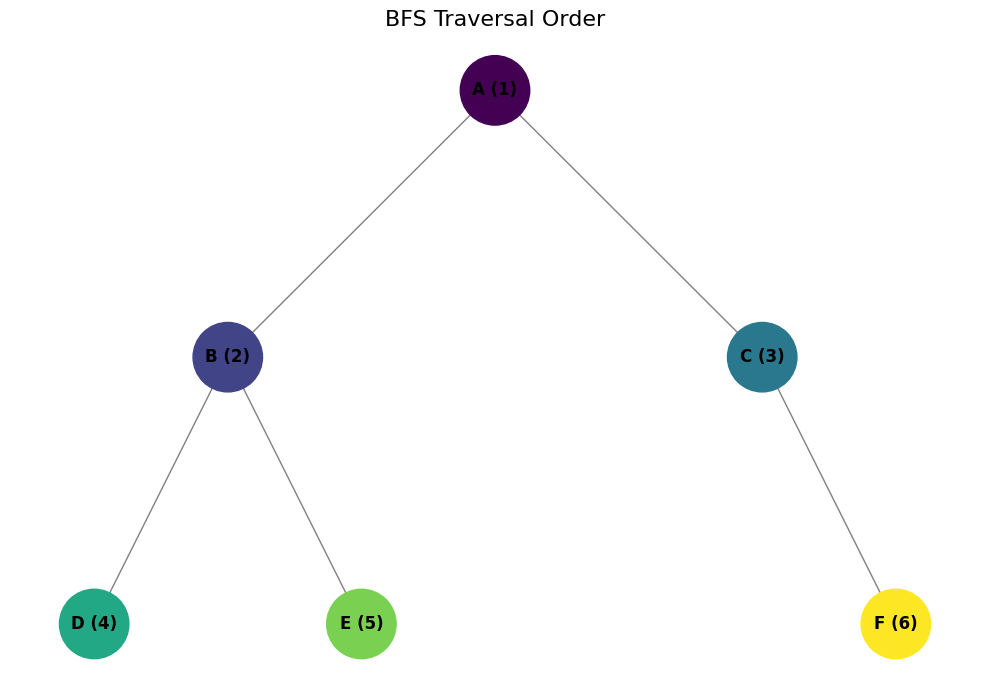

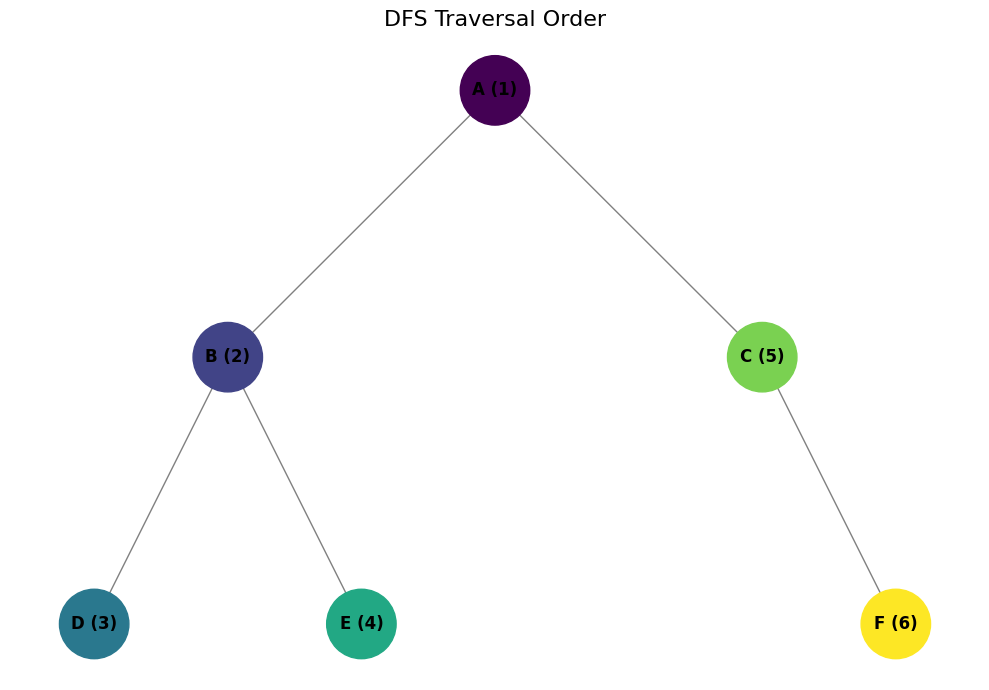

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# 1. Store the graph using an adjacency list (a Python dictionary).
# Assuming the tree structure based on the description: A is root, A -> (B, C), B -> (D, E), C -> (F)
tree_adj_list = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# Edges for drawing the graph using networkx
tree_edges = [
    ('A', 'B'), ('A', 'C'),
    ('B', 'D'), ('B', 'E'),
    ('C', 'F')
]

# 2. Perform a BFS traversal starting from node A.
def bfs(graph, start_node):
    visited = set()
    queue = deque([start_node])
    bfs_order = []

    visited.add(start_node)

    while queue:
        node = queue.popleft()
        bfs_order.append(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return bfs_order

# 3. Performs a DFS traversal starting from node A.
def dfs(graph, start_node):
    visited = set()
    dfs_order = []

    def _dfs_recursive(node):
        visited.add(node)
        dfs_order.append(node)
        # Sort neighbors for consistent order if graph is undirected or for specific traversal order
        # For a tree, the order in adjacency list is fine.
        for neighbor in graph[node]:
            if neighbor not in visited:
                _dfs_recursive(neighbor)

    _dfs_recursive(start_node)
    return dfs_order

# Function to draw the graph with traversal order highlighted
def draw_traversal(graph_edges, traversal_order, title):
    G = nx.DiGraph() # Use a directed graph for the tree
    G.add_edges_from(graph_edges)

    # Manual hierarchical layout for clarity for this specific tree
    pos = {
        'A': (0, 3),
        'B': (-1, 2), 'C': (1, 2),
        'D': (-1.5, 1), 'E': (-0.5, 1), 'F': (1.5, 1)
    }

    plt.figure(figsize=(10, 7))

    node_colors_map = plt.cm.viridis # Colormap for visualizing order
    max_order = len(traversal_order)
    node_colors = []
    node_labels = {}
    node_sizes = []

    for node in G.nodes():
        if node in traversal_order:
            order_index = traversal_order.index(node)
            # Normalize index for colormap (handle case max_order=1 if needed, though not here)
            normalized_index = order_index / (max_order - 1) if max_order > 1 else 0.5
            node_colors.append(node_colors_map(normalized_index))
            node_labels[node] = f"{node} ({order_index + 1})" # Label with node and order
            node_sizes.append(2500) # Larger size for visited nodes
        else:
            node_colors.append('lightgrey') # Fallback for unvisited (should not happen for full traversal)
            node_labels[node] = node
            node_sizes.append(1500)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_weight='bold')

    plt.title(title, fontsize=16)
    plt.axis('off') # Hide axes
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

# Perform traversals
bfs_order = bfs(tree_adj_list, 'A')
dfs_order = dfs(tree_adj_list, 'A')

# 4. Print both traversal orders
print(f"BFS Traversal Order: {bfs_order}")
print(f"DFS Traversal Order: {dfs_order}")

# Draw two separate tree diagrams
draw_traversal(tree_edges, bfs_order, 'BFS Traversal Order')
draw_traversal(tree_edges, dfs_order, 'DFS Traversal Order')